In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Matikan warning agar notebook terlihat rapi
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil dimuat!")

✅ Library berhasil dimuat!


In [2]:
# Label kelas yang digunakan
labels = ['Positive', 'Neutral', 'Negative']

# 1. GROUND TRUTH (Label Asli)
# Terdiri dari: 3 Positive, 2 Neutral, 5 Negative (Total 10 sampel)
y_true = (['Positive'] * 3) + (['Neutral'] * 2) + (['Negative'] * 5)

# 2. PREDIKSI MODEL INDOBERT MURNI
# Kesalahan: 4 sampel Negative diprediksi sebagai Neutral, 1 Positive jadi Neutral
y_pred_pure = ['Positive', 'Positive', 'Neutral'] + \
              ['Neutral', 'Neutral'] + \
              ['Neutral', 'Neutral', 'Neutral', 'Neutral', 'Negative']

# 3. PREDIKSI MODEL HYBRID LOGIC (Rule-Based)
# Koreksi: 4 sampel Negative berhasil diprediksi benar, sisa 1 jadi Neutral
y_pred_hybrid = ['Positive', 'Positive', 'Neutral'] + \
                ['Neutral', 'Neutral'] + \
                ['Neutral', 'Negative', 'Negative', 'Negative', 'Negative']

print("✅ Data Ground Truth dan Prediksi berhasil dibuat!")

✅ Data Ground Truth dan Prediksi berhasil dibuat!


In [3]:
print("="*55)
print("HASIL EVALUASI 1: INDOBERT MURNI (PURE MODEL)")
print("="*55)
report_pure = classification_report(y_true, y_pred_pure, labels=labels, digits=2)
print(report_pure)

print("\n" + "="*55)
print("HASIL EVALUASI 2: INDOBERT + HYBRID LOGIC")
print("="*55)
report_hybrid = classification_report(y_true, y_pred_hybrid, labels=labels, digits=2)
print(report_hybrid)

HASIL EVALUASI 1: INDOBERT MURNI (PURE MODEL)
              precision    recall  f1-score   support

    Positive       1.00      0.67      0.80         3
     Neutral       0.29      1.00      0.44         2
    Negative       1.00      0.20      0.33         5

    accuracy                           0.50        10
   macro avg       0.76      0.62      0.53        10
weighted avg       0.86      0.50      0.50        10


HASIL EVALUASI 2: INDOBERT + HYBRID LOGIC
              precision    recall  f1-score   support

    Positive       1.00      0.67      0.80         3
     Neutral       0.50      1.00      0.67         2
    Negative       1.00      0.80      0.89         5

    accuracy                           0.80        10
   macro avg       0.83      0.82      0.79        10
weighted avg       0.90      0.80      0.82        10



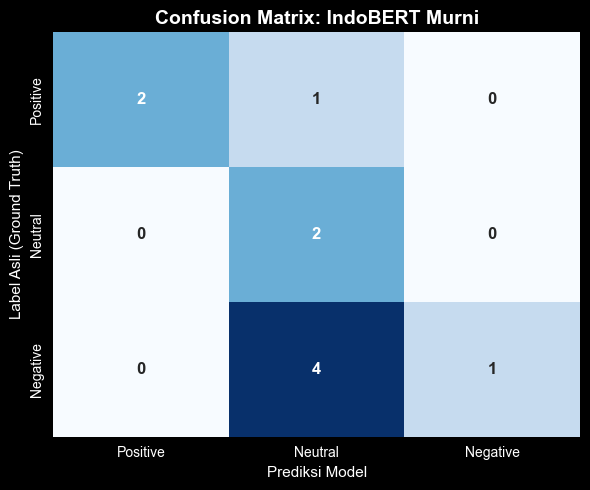

In [4]:
# Hitung matriks
cm_pure = confusion_matrix(y_true, y_pred_pure, labels=labels)

# Konfigurasi plot (Dark mode + warna Biru)
plt.style.use('dark_background')
plt.figure(figsize=(6, 5))
sns.heatmap(cm_pure, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, cbar=False,
            annot_kws={"size": 12, "weight": "bold"})

# Labeling
plt.title('Confusion Matrix: IndoBERT Murni', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Label Asli (Ground Truth)', fontsize=11)
plt.tight_layout()
plt.show()

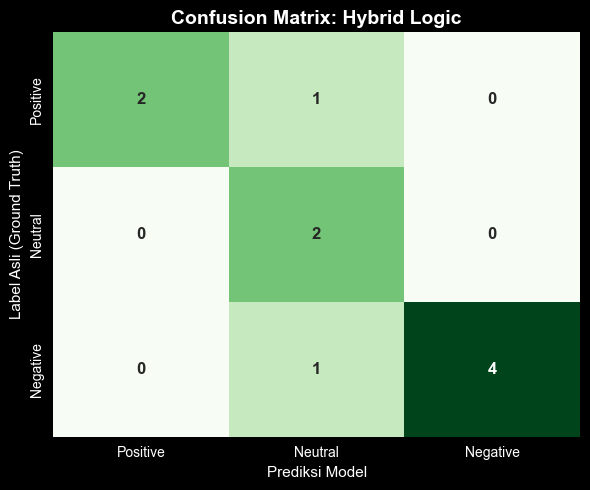

In [5]:
# Hitung matriks
cm_hybrid = confusion_matrix(y_true, y_pred_hybrid, labels=labels)

# Konfigurasi plot (Dark mode + warna Hijau)
plt.style.use('dark_background')
plt.figure(figsize=(6, 5))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, cbar=False,
            annot_kws={"size": 12, "weight": "bold"})

# Labeling
plt.title('Confusion Matrix: Hybrid Logic', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Label Asli (Ground Truth)', fontsize=11)
plt.tight_layout()
plt.show()

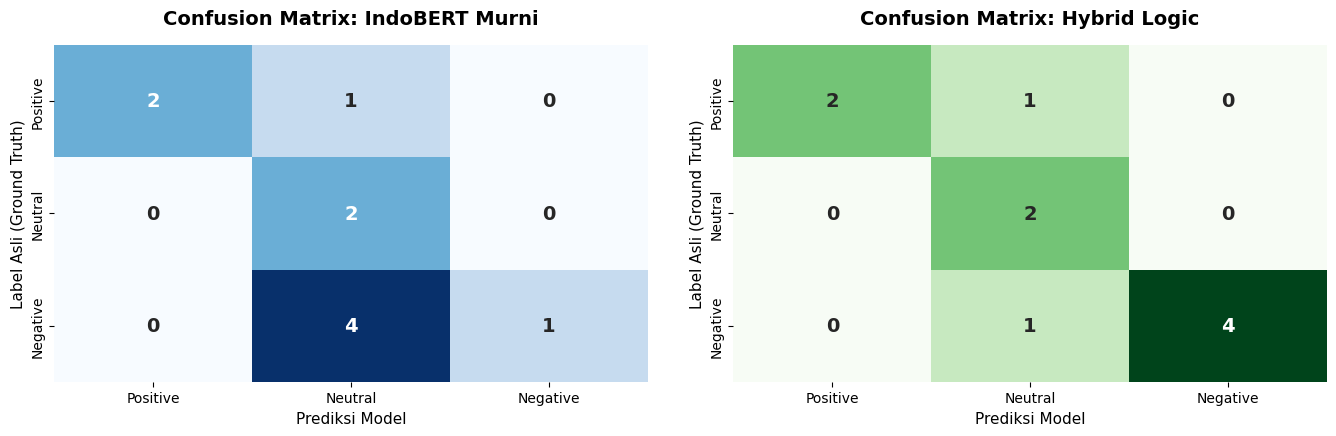

In [7]:
# Setup tema putih untuk skripsi
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Font style untuk angka di dalam matriks
annot_kws = {"size": 14, "weight": "bold"}

# --- PLOT 1: IndoBERT Murni (Kiri) ---
sns.heatmap(cm_pure, ax=axes[0], annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, cbar=False,
            annot_kws=annot_kws)
axes[0].set_title('Confusion Matrix: IndoBERT Murni', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Prediksi Model', fontsize=11)
axes[0].set_ylabel('Label Asli (Ground Truth)', fontsize=11)

# --- PLOT 2: Hybrid Logic (Kanan) ---
sns.heatmap(cm_hybrid, ax=axes[1], annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, cbar=False,
            annot_kws=annot_kws)
axes[1].set_title('Confusion Matrix: Hybrid Logic', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Prediksi Model', fontsize=11)
axes[1].set_ylabel('Label Asli (Ground Truth)', fontsize=11)

# Atur jarak biar rapi dan tampilkan
plt.tight_layout(pad=3.0)
plt.show()